# Ablation Study — CIFAR-10
ANN-classifier runs only (`classifier.type != 'snn'`).

In [8]:
import json, glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

ROOT    = Path().resolve().parent.parent.parent   # repo root
OUT_DIR = Path().resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 140, "axes.titlesize": 11, "axes.labelsize": 10})

FULL_MODEL_PATH = ROOT / "logs/core_experiments/full_routing/cifar10/cats/carson/run_001"

def save(fig, name):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved → {path}")

In [9]:
# ── Auto-discover CIFAR-10 CARSON ablation runs; keep only ANN classifier ────
ABLATION_ROOT = ROOT / "logs" / "ablation_study"

LABELS = {
    "fixed_tau":                             "Fixed τ (non-learnable)",
    "fixed_threshold":                       "Fixed θ (non-learnable)",
    "no_adaptive":                           "No adaptive threshold (θ_adapt off)",
    "fixed_tau_fixed_threshold":             "Fixed τ + fixed θ",
    "fixed_tau_fixed_threshold_no_adaptive": "Fully static (τ, θ, no adapt)",
    "no_inhibition":                         "No inhibitory population",
    "no_positional":                         "No RoPE positional encoding",
    "no_spiking":                            "No spiking (ANN after routing)",
}

# Preferred display order matching the thesis table
CARSON_ORDER = [
    "fixed_tau",
    "fixed_threshold",
    "no_adaptive",
    "fixed_tau_fixed_threshold",
    "fixed_tau_fixed_threshold_no_adaptive",
    "no_inhibition",
    "no_positional",
    "no_spiking",
]

# ── Old-style flat paths: runs stored before the new sub-dir structure ─────────
# fixed_tau cifar10 carson was run as ablation_study/carson/run_002 on another machine
OLD_STYLE_OVERRIDES = {
    # cond -> explicit log dir (no cifar10/cats/carson sub-dirs)
    "fixed_tau": ABLATION_ROOT / "carson" / "run_001",
}


def _load_run(cfg_path, cond, routing_key):
    """Return a dict for one run, or None if it should be skipped."""
    cfg = json.loads(cfg_path.read_text())
    exp = cfg.get("experiment", {})
    routing = exp.get("routing_type", "unknown")
    if routing != routing_key:
        return None
    clf_type = cfg.get("classifier", {}).get("type", "NOT SET")
    if clf_type == "snn":
        return None                     # skip SNN classifier runs

    run_name     = exp.get("run_name", cfg_path.parent.name)
    metrics_file = cfg_path.parent / "best_metrics.json"
    train_log    = cfg_path.parent / "train_log.csv"

    if not metrics_file.exists():
        return None                     # incomplete — will show status below

    metrics = json.loads(metrics_file.read_text())
    v = metrics["val_metrics"]
    return {
        "cond":        cond,
        "routing":     routing,
        "run_name":    run_name,
        "label":       LABELS.get(cond, cond),
        "log_dir":     cfg_path.parent,
        "train_log":   train_log if train_log.exists() else None,
        "val_f1":      v["f1"],
        "val_acc":     v["accuracy"],
        "best_epoch":  metrics["best_epoch"],
        "spk_samp":    v.get("val_spikes_per_sample", float("nan")),
        "spk_tok":     v.get("val_spikes_per_token",  float("nan")),
        "exc_rate":    v.get("val_exc_firing_rate",   float("nan")),
        "inh_rate":    v.get("val_inh_firing_rate",   float("nan")),
        "entropy":     v.get("val_routing_entropy",   float("nan")),
        "routing_var": v.get("val_routing_variance",  float("nan")),
        "dominance":   v.get("val_dominance_fraction",float("nan")),
    }


# ── Primary discovery: new-style paths  */{cond}/cifar10/**/config.json ───────
runs = []
found_conds = set()

for cfg_path in sorted(ABLATION_ROOT.glob("*/cifar10/**/config.json")):
    cond = cfg_path.parts[cfg_path.parts.index("ablation_study") + 1]
    row  = _load_run(cfg_path, cond, "carson")
    if row is not None:
        runs.append(row)
        found_conds.add(cond)

# ── Fallback: old-style flat paths ────────────────────────────────────────────
for cond, log_dir in OLD_STYLE_OVERRIDES.items():
    if cond in found_conds:
        continue                        # already discovered via new-style path
    cfg_path = log_dir / "config.json"
    if not cfg_path.exists():
        continue
    row = _load_run(cfg_path, cond, "carson")
    if row is not None:
        runs.append(row)
        found_conds.add(cond)

# ── Full model baseline (core experiment, CARSON) ─────────────────────────────
fm_cfg = json.loads((FULL_MODEL_PATH / "config.json").read_text())
assert fm_cfg.get("classifier", {}).get("type", "NOT SET") != "snn", \
    "Full model uses SNN classifier — check FULL_MODEL_PATH"
fm_m = json.loads((FULL_MODEL_PATH / "best_metrics.json").read_text())
fv   = fm_m["val_metrics"]
full_model = {
    "cond":        "full_model",
    "routing":     "carson",
    "run_name":    "run_001",
    "label":       "Full model (CARSON, all adaptive)",
    "log_dir":     FULL_MODEL_PATH,
    "train_log":   FULL_MODEL_PATH / "train_log.csv",
    "val_f1":      fv["f1"],
    "val_acc":     fv["accuracy"],
    "best_epoch":  fm_m["best_epoch"],
    "spk_samp":    fv.get("val_spikes_per_sample", float("nan")),
    "spk_tok":     fv.get("val_spikes_per_token",  float("nan")),
    "exc_rate":    fv.get("val_exc_firing_rate",   float("nan")),
    "inh_rate":    fv.get("val_inh_firing_rate",   float("nan")),
    "entropy":     fv.get("val_routing_entropy",   float("nan")),
    "routing_var": fv.get("val_routing_variance",  float("nan")),
    "dominance":   fv.get("val_dominance_fraction",float("nan")),
}

# ── Build master dataframe ────────────────────────────────────────────────────
df_all = pd.DataFrame([full_model] + runs)
order_map = {c: i for i, c in enumerate(["full_model"] + CARSON_ORDER)}
df_all["_order"] = df_all["cond"].map(order_map).fillna(99)
df_all = df_all.sort_values("_order").reset_index(drop=True)

full_f1 = df_all.loc[df_all["cond"] == "full_model", "val_f1"].values[0]
df_all["delta_f1_pp"] = (df_all["val_f1"] - full_f1) * 100

# ── Per-condition status report ───────────────────────────────────────────────
print(f"Loaded {len(df_all)} CARSON ANN runs (incl. full model baseline)\n")
print(f"{'Condition':<45} {'Status'}")
print("-" * 65)
for cond in ["full_model"] + CARSON_ORDER:
    in_df = cond in df_all["cond"].values
    # Check if config exists but metrics are missing (started but incomplete)
    incomplete = False
    if not in_df:
        for search_root in [ABLATION_ROOT / cond / "cifar10",
                            OLD_STYLE_OVERRIDES.get(cond, Path("/nonexistent"))]:
            cfg_candidates = list(search_root.glob("**/config.json")) if search_root.exists() else []
            if cfg_candidates or (OLD_STYLE_OVERRIDES.get(cond, Path("/nonexistent")) / "config.json").exists():
                incomplete = True
                break
    status = "✓ complete" if in_df else ("✗ started, no metrics yet" if incomplete else "✗ not started / not found")
    print(f"  {cond:<43} {status}")

print()
print(df_all[["cond", "run_name", "val_f1", "val_acc", "delta_f1_pp"]].to_string(index=False))

Loaded 9 CARSON ANN runs (incl. full model baseline)

Condition                                     Status
-----------------------------------------------------------------
  full_model                                  ✓ complete
  fixed_tau                                   ✓ complete
  fixed_threshold                             ✓ complete
  no_adaptive                                 ✓ complete
  fixed_tau_fixed_threshold                   ✓ complete
  fixed_tau_fixed_threshold_no_adaptive       ✓ complete
  no_inhibition                               ✓ complete
  no_positional                               ✓ complete
  no_spiking                                  ✓ complete

                                 cond run_name   val_f1  val_acc  delta_f1_pp
                           full_model  run_001 0.675364   0.6756     0.000000
                            fixed_tau  run_001 0.680179   0.6810     0.481521
                      fixed_threshold  run_001 0.679528   0.6802     0.416334
 

## 1. Summary Table (CARSON routing — matches thesis Table)

In [10]:
display_cols = {
    "label":        "Configuration",
    "val_f1":       "Val F1",
    "val_acc":      "Val Acc",
    "delta_f1_pp":  "ΔF1 (pp)",
    "spk_samp":     "Spk/Samp",
    "spk_tok":      "Spk/Tok",
    "entropy":      "H",
    "exc_rate":     "Exc",
    "inh_rate":     "Inh",
    "best_epoch":   "Best Ep.",
}

# Show all expected conditions, marking incomplete ones explicitly
all_cond_labels = {"full_model": "Full model (CARSON, all adaptive)", **LABELS}
rows_for_display = []
for cond in ["full_model"] + CARSON_ORDER:
    match = df_all[df_all["cond"] == cond]
    if not match.empty:
        rows_for_display.append(match.iloc[0][list(display_cols)].rename(display_cols))
    else:
        placeholder = {v: float("nan") for v in display_cols.values()}
        placeholder["Configuration"] = all_cond_labels.get(cond, cond) + "  [INCOMPLETE]"
        rows_for_display.append(pd.Series(placeholder))

tbl = pd.DataFrame(rows_for_display).reset_index(drop=True)
fmt = {
    "Val F1":    "{:.4f}",
    "Val Acc":   "{:.4f}",
    "ΔF1 (pp)":  "{:+.2f}",
    "Spk/Samp":  "{:.0f}",
    "Spk/Tok":   "{:.1f}",
    "H":         "{:.3f}",
    "Exc":       "{:.3f}",
    "Inh":       "{:.3f}",
}
tbl.style.format(fmt, na_rep="—") \
    .bar(subset=["ΔF1 (pp)"], align="zero", color=["#f4a582","#92c5de"]) \
    .set_caption("Ablation study — CIFAR-10, CARSON routing, ANN classifier runs only")

,Configuration,Val F1,Val Acc,ΔF1 (pp),Spk/Samp,Spk/Tok,H,Exc,Inh,Best Ep.
0,"Full model (CARSON, all adaptive)",0.6754,0.6756,+0.00,2383,36.7,0.490,0.180,0.106,6
1,Fixed τ (non-learnable),0.6802,0.6810,+0.48,2271,34.9,0.457,0.160,0.113,7
2,Fixed θ (non-learnable),0.6795,0.6802,+0.42,2268,34.9,0.455,0.157,0.115,7
3,No adaptive threshold (θ_adapt off),0.6797,0.6804,+0.44,2731,42.0,0.465,0.187,0.141,7
4,Fixed τ + fixed θ,0.6820,0.6858,+0.66,2365,36.4,0.491,0.179,0.106,6
5,"Fully static (τ, θ, no adapt)",0.6799,0.6836,+0.45,2851,43.9,0.496,0.207,0.136,6
6,No inhibitory population,0.6764,0.6768,+0.10,2952,45.4,0.477,0.177,—,5
7,No RoPE positional encoding,0.6755,0.6766,+0.01,3225,49.6,0.589,0.151,0.237,5
8,No spiking (ANN after routing),0.6741,0.6784,-0.13,—,—,0.597,—,—,6


## 2. ΔF1 — Component Contribution (CARSON)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\2_delta_f1_carson.png


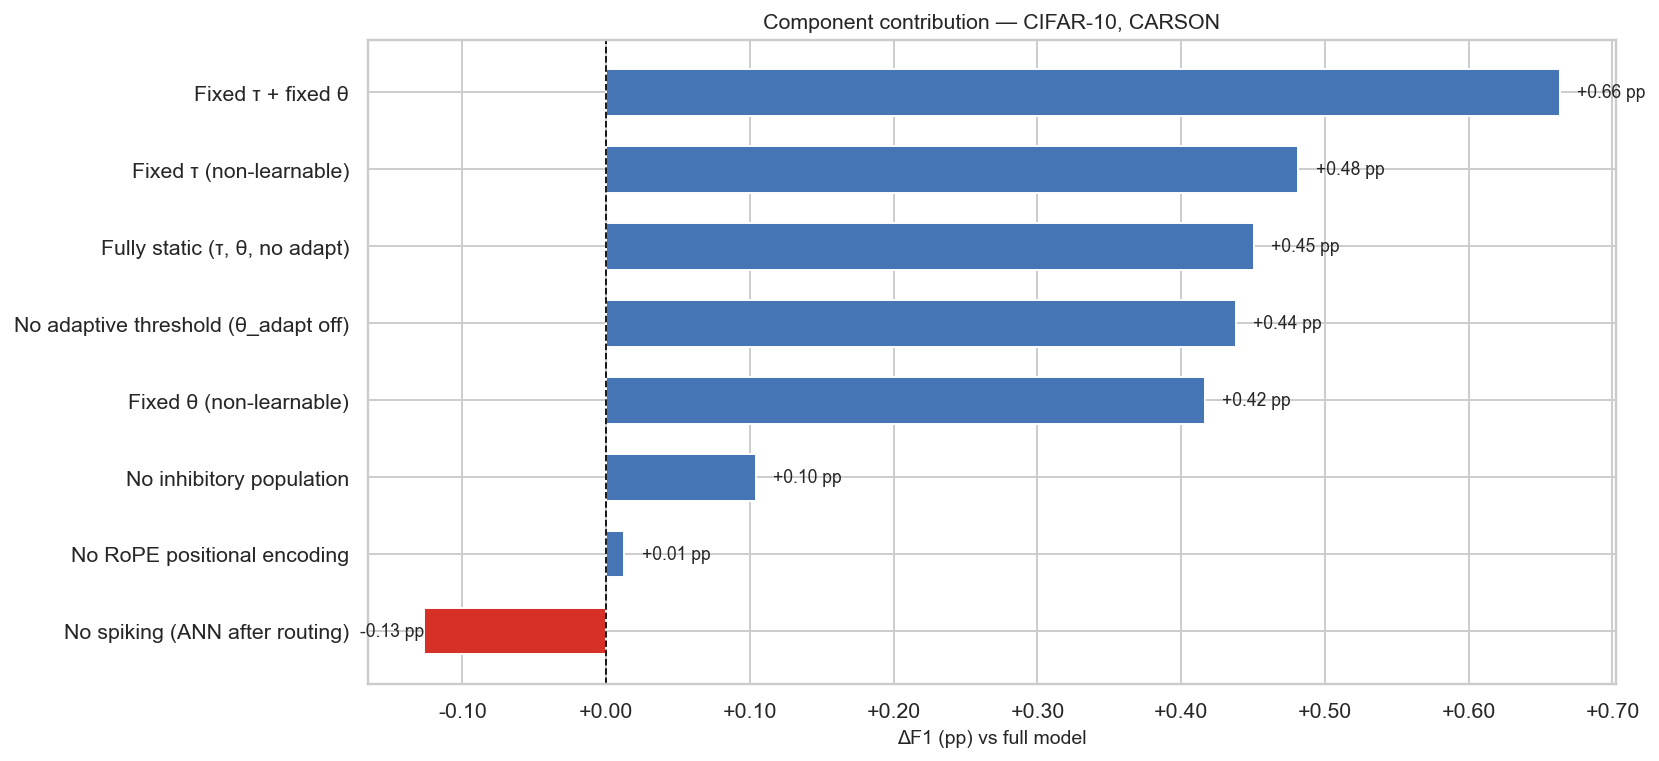

In [11]:
abl = df_all[df_all["cond"] != "full_model"].dropna(subset=["delta_f1_pp"]).copy()
abl = abl.sort_values("delta_f1_pp")

colors = ["#d73027" if v < 0 else "#4575b4" for v in abl["delta_f1_pp"]]

fig, ax = plt.subplots(figsize=(12, 0.55 * len(abl) + 1.2))
bars = ax.barh(abl["label"], abl["delta_f1_pp"], color=colors, edgecolor="white", height=0.6)
ax.axvline(0, color="black", linewidth=0.9, linestyle="--")
for bar, val in zip(bars, abl["delta_f1_pp"]):
    offset = 0.012 if val >= 0 else 0.0
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f} pp", va="center", ha=ha, fontsize=9)
ax.set(xlabel="ΔF1 (pp) vs full model", title="Component contribution — CIFAR-10, CARSON")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%+.2f"))
fig.tight_layout()
save(fig, "2_delta_f1_carson")
plt.show()

## 3. Val F1 & Val Acc — Grouped Bar (CARSON)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\3_perf_grouped_bar_carson.png


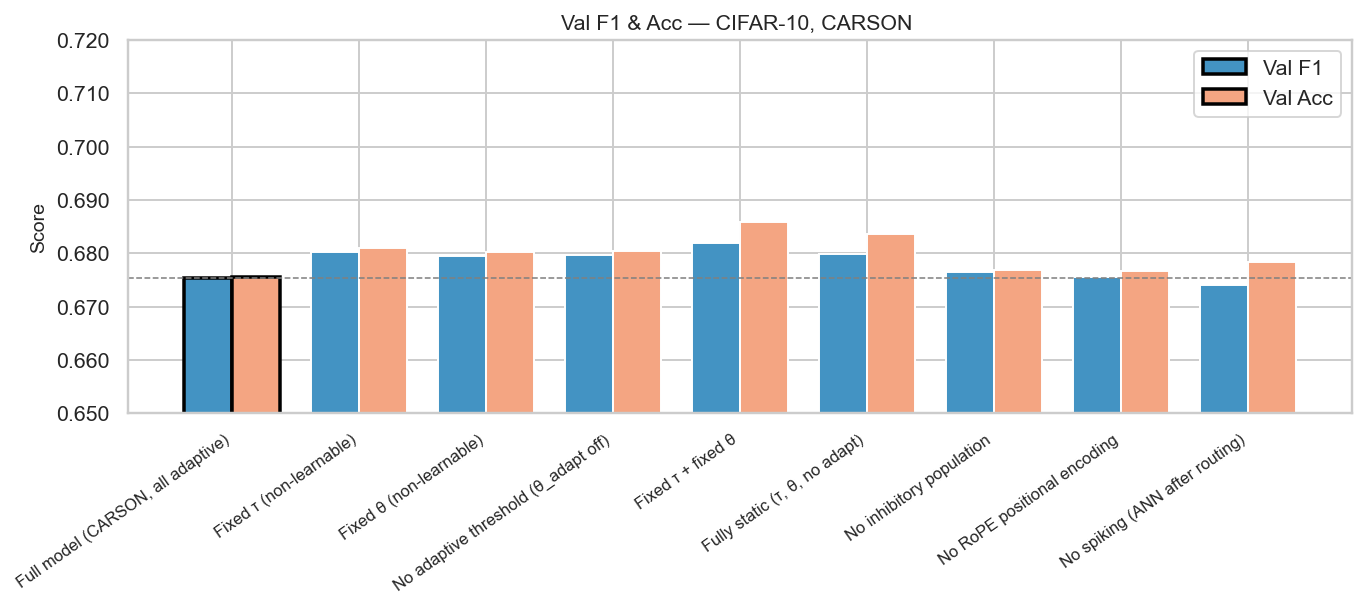

In [12]:
x     = np.arange(len(df_all))
width = 0.38
labels   = df_all["label"].tolist()
is_full  = df_all["cond"] == "full_model"

fig, ax = plt.subplots(figsize=(max(10, len(df_all) * 1.1), 4.5))
b1 = ax.bar(x - width/2, df_all["val_f1"],  width, label="Val F1",  color="#4393c3")
b2 = ax.bar(x + width/2, df_all["val_acc"], width, label="Val Acc", color="#f4a582")

for i, (bar1, bar2) in enumerate(zip(b1, b2)):
    if is_full.iloc[i]:
        bar1.set_edgecolor("black"); bar1.set_linewidth(1.8)
        bar2.set_edgecolor("black"); bar2.set_linewidth(1.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8.5)
ax.set(ylabel="Score", title="Val F1 & Acc — CIFAR-10, CARSON ")
ax.set_ylim(0.65, 0.72)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.axhline(full_f1, color="grey", linewidth=0.8, linestyle="--")
ax.legend()
fig.tight_layout()
save(fig, "3_perf_grouped_bar_carson")
plt.show()

## 4. Spiking Efficiency — Spk/Samp & Spk/Tok (CARSON)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\4_spiking_efficiency_carson.png


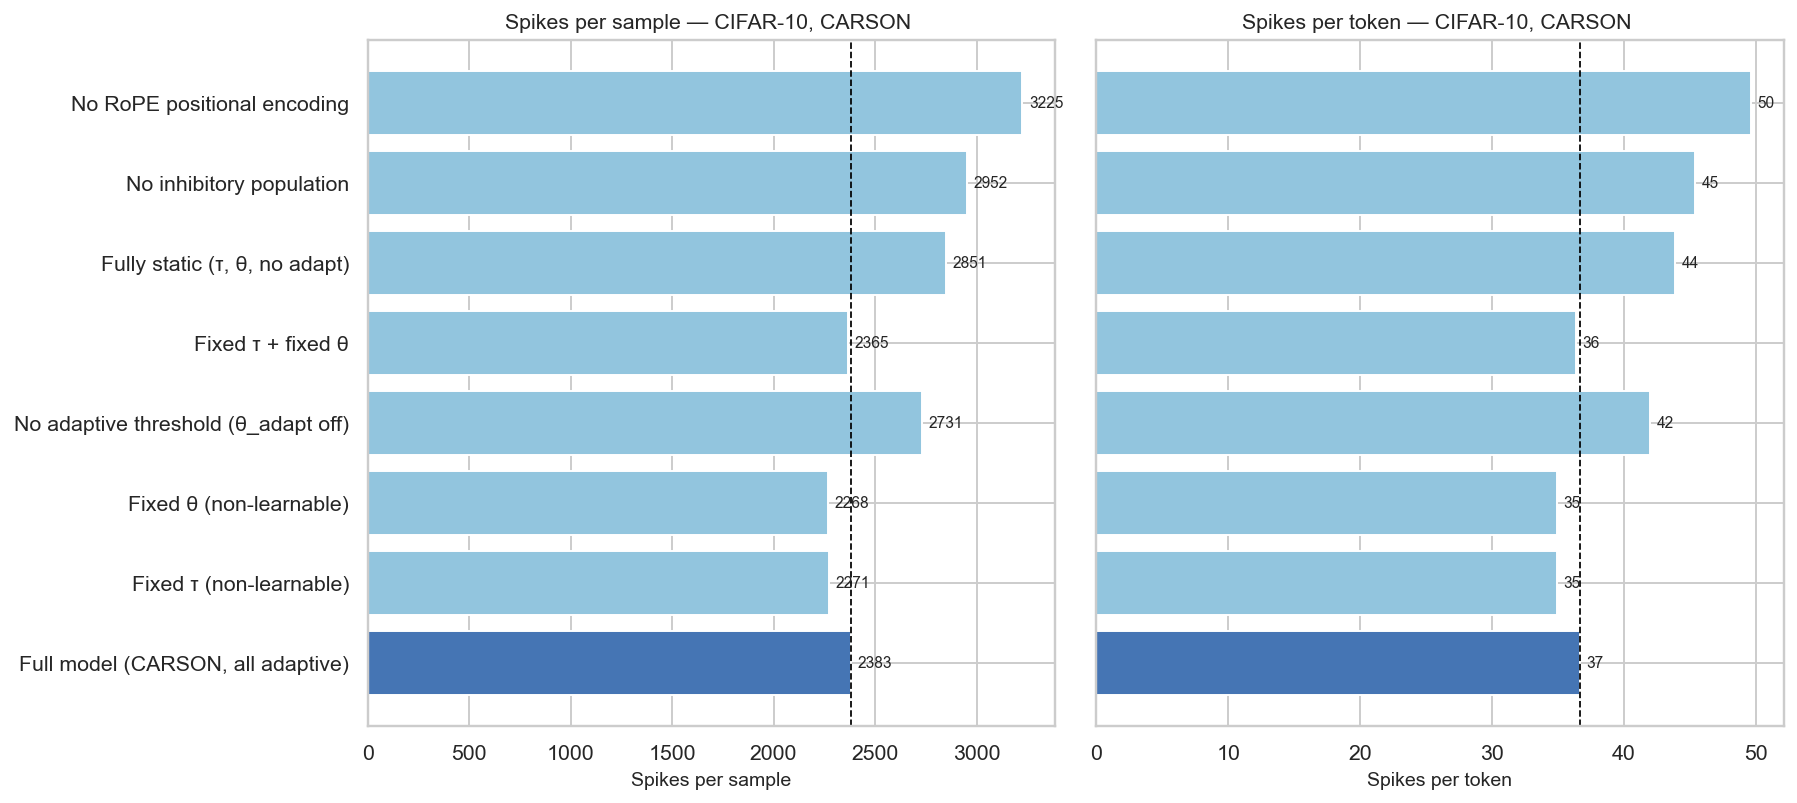

In [13]:
spiking_rows = df_all.dropna(subset=["spk_samp"])

fig, axes = plt.subplots(1, 2, figsize=(13, 0.55 * len(spiking_rows) + 1.5), sharey=True)
for ax, col, title in zip(
        axes,
        ["spk_samp", "spk_tok"],
        ["Spikes per sample", "Spikes per token"]):
    vals   = spiking_rows[col]
    colors = ["#4575b4" if r["cond"] == "full_model" else "#92c5de"
              for _, r in spiking_rows.iterrows()]
    bars = ax.barh(spiking_rows["label"], vals, color=colors, edgecolor="white")
    ref  = df_all.loc[df_all["cond"] == "full_model", col].values[0]
    ax.axvline(ref, color="black", linewidth=0.9, linestyle="--")
    for bar, val in zip(bars, vals):
        ax.text(val + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}", va="center", fontsize=8)
    ax.set(xlabel=title, title=title + " — CIFAR-10, CARSON ")
fig.tight_layout()
save(fig, "4_spiking_efficiency_carson")
plt.show()

## 5. Excitatory / Inhibitory Firing Rates (CARSON)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\5_exc_inh_rates_carson.png


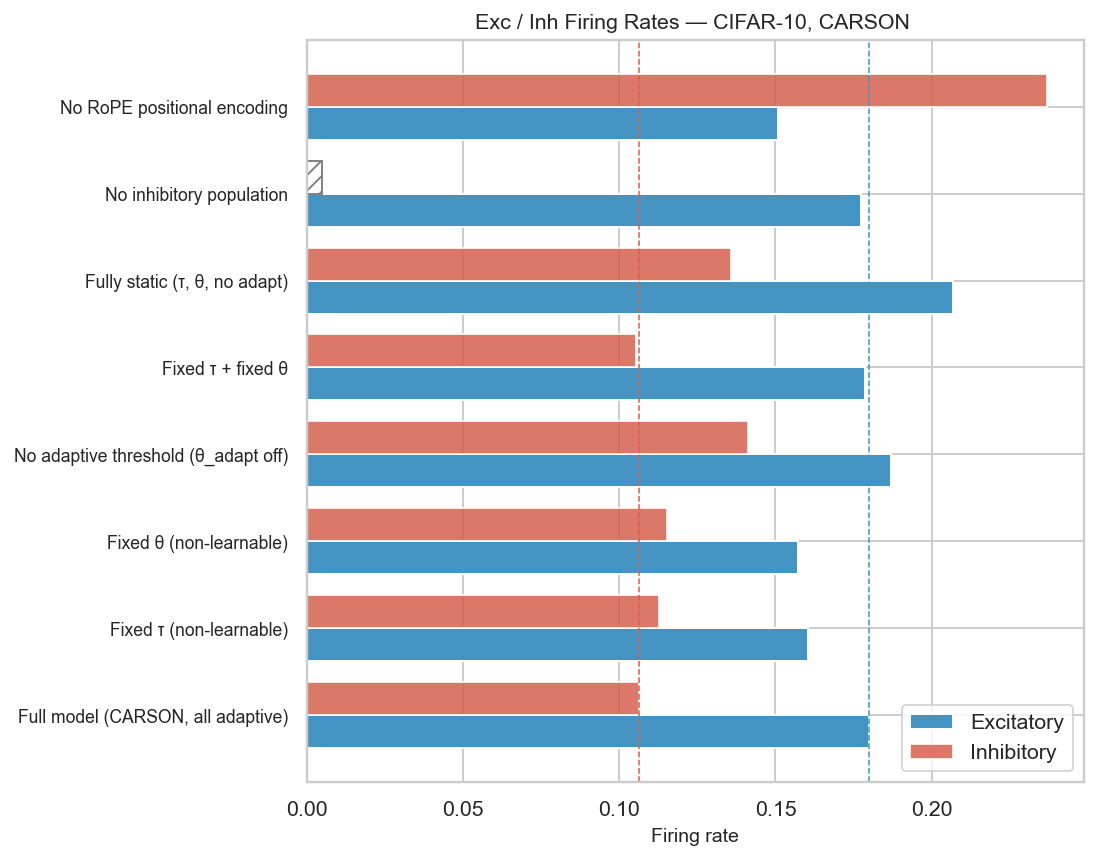

In [14]:
exc_inh_rows = df_all.dropna(subset=["exc_rate"])
y     = np.arange(len(exc_inh_rows))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 0.6 * len(exc_inh_rows) + 1.5))
ax.barh(y - width/2, exc_inh_rows["exc_rate"], width, label="Excitatory", color="#4393c3")
ax.barh(y + width/2, exc_inh_rows["inh_rate"].fillna(0), width,
        label="Inhibitory", color="#d6604d", alpha=0.85)

# hatch bars where inhibitory is N/A
for i, (_, row) in enumerate(exc_inh_rows.iterrows()):
    if np.isnan(row["inh_rate"]):
        ax.barh(y[i] + width/2, 0.005, width, color="none",
                edgecolor="grey", hatch="///", label="_nolegend_")

full_exc = df_all.loc[df_all["cond"] == "full_model", "exc_rate"].values[0]
full_inh = df_all.loc[df_all["cond"] == "full_model", "inh_rate"].values[0]
ax.axvline(full_exc, color="#4393c3", linewidth=0.8, linestyle="--")
ax.axvline(full_inh, color="#d6604d",  linewidth=0.8, linestyle="--")

ax.set_yticks(y)
ax.set_yticklabels(exc_inh_rows["label"], fontsize=9)
ax.set(xlabel="Firing rate", title="Exc / Inh Firing Rates — CIFAR-10, CARSON ")
ax.legend()
fig.tight_layout()
save(fig, "5_exc_inh_rates_carson")
plt.show()

## 6. Routing Entropy & Variance (CARSON)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\6_routing_metrics_carson.png


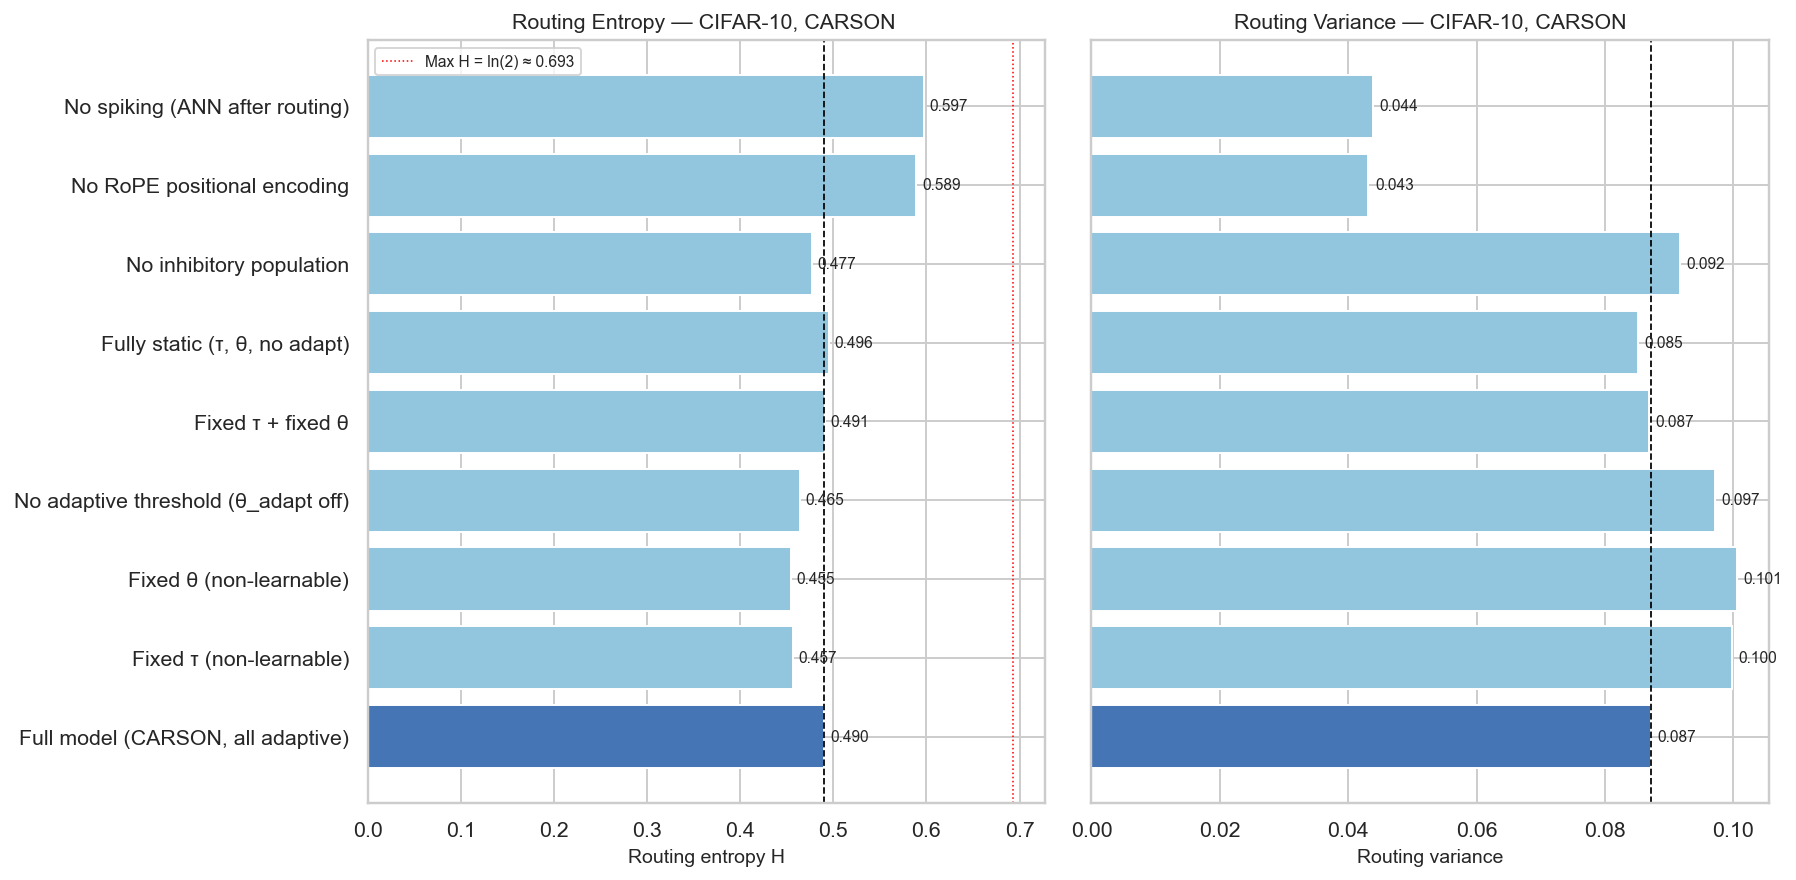

In [15]:
import math
MAX_ENTROPY = math.log(2)   # log(num_groups=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 0.55 * len(df_all) + 1.5), sharey=True)

for ax, col, xlabel in zip(
        axes,
        ["entropy", "routing_var"],
        ["Routing entropy H", "Routing variance"]):
    vals   = df_all[col]
    colors = ["#4575b4" if r["cond"] == "full_model" else "#92c5de"
              for _, r in df_all.iterrows()]
    bars = ax.barh(df_all["label"], vals, color=colors, edgecolor="white")
    ref  = df_all.loc[df_all["cond"] == "full_model", col].values[0]
    ax.axvline(ref, color="black", linewidth=0.9, linestyle="--")
    for bar, val in zip(bars, vals):
        ax.text(val + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)
    ax.set(xlabel=xlabel)

axes[0].axvline(MAX_ENTROPY, color="red", linewidth=0.8, linestyle=":",
                label=f"Max H = ln(2) ≈ {MAX_ENTROPY:.3f}")
axes[0].legend(fontsize=8)
axes[0].set_title("Routing Entropy — CIFAR-10, CARSON ")
axes[1].set_title("Routing Variance — CIFAR-10, CARSON")
fig.tight_layout()
save(fig, "6_routing_metrics_carson")
plt.show()

## 7. Training Curves — Val F1 per epoch (all CARSON ANN runs)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\7a_training_curves_val_f1_carson.png


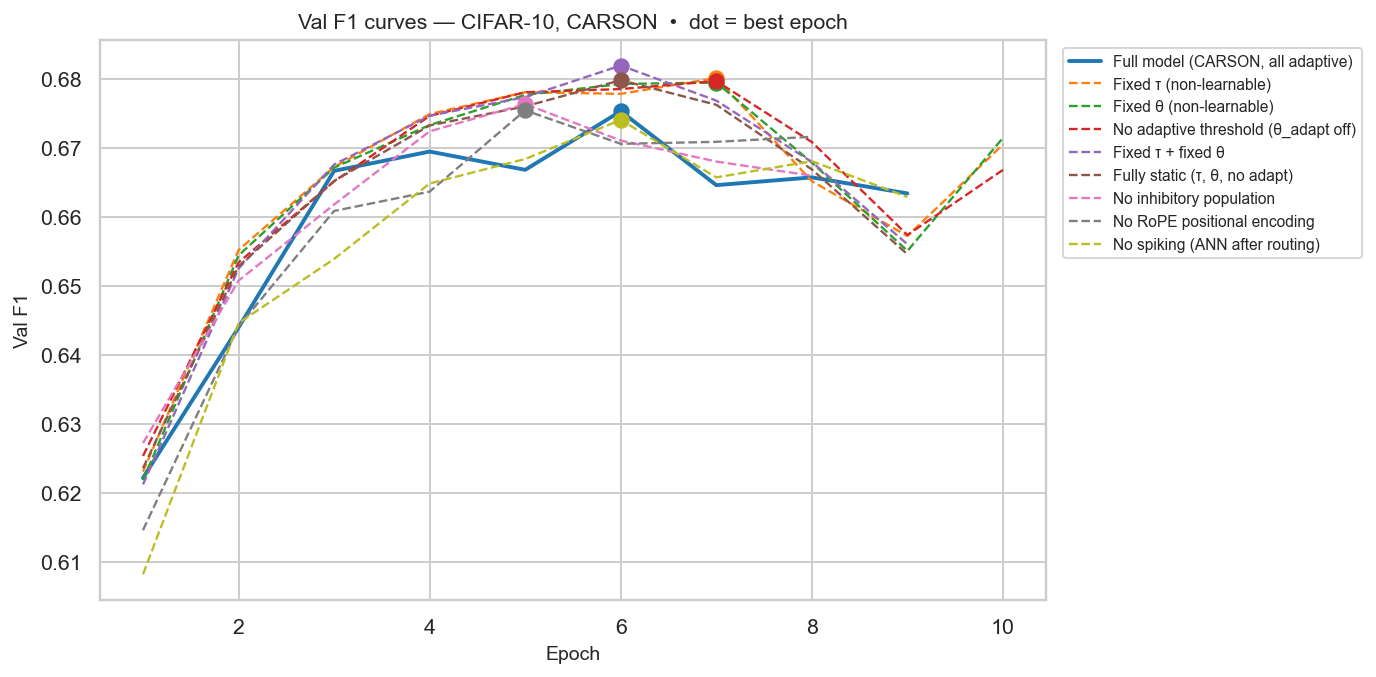

In [16]:
palette = sns.color_palette("tab10", n_colors=len(df_all))

fig, ax = plt.subplots(figsize=(10, 5))
for (_, row), color in zip(df_all.iterrows(), palette):
    if row["train_log"] is None or not Path(row["train_log"]).exists():
        continue
    tl = pd.read_csv(row["train_log"])
    lw = 2.0 if row["cond"] == "full_model" else 1.2
    ls = "-"  if row["cond"] == "full_model" else "--"
    ax.plot(tl["epoch"], tl["val_f1"], label=row["label"],
            color=color, linewidth=lw, linestyle=ls)
    best_ep  = row["best_epoch"]
    best_f1  = tl.loc[tl["epoch"] == best_ep, "val_f1"]
    if not best_f1.empty:
        ax.scatter(best_ep, best_f1.values[0], color=color, s=55, zorder=5)

ax.set(xlabel="Epoch", ylabel="Val F1",
       title="Val F1 curves — CIFAR-10, CARSON  •  dot = best epoch")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
save(fig, "7a_training_curves_val_f1_carson")
plt.show()

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\7b_training_curves_spk_samp_carson.png


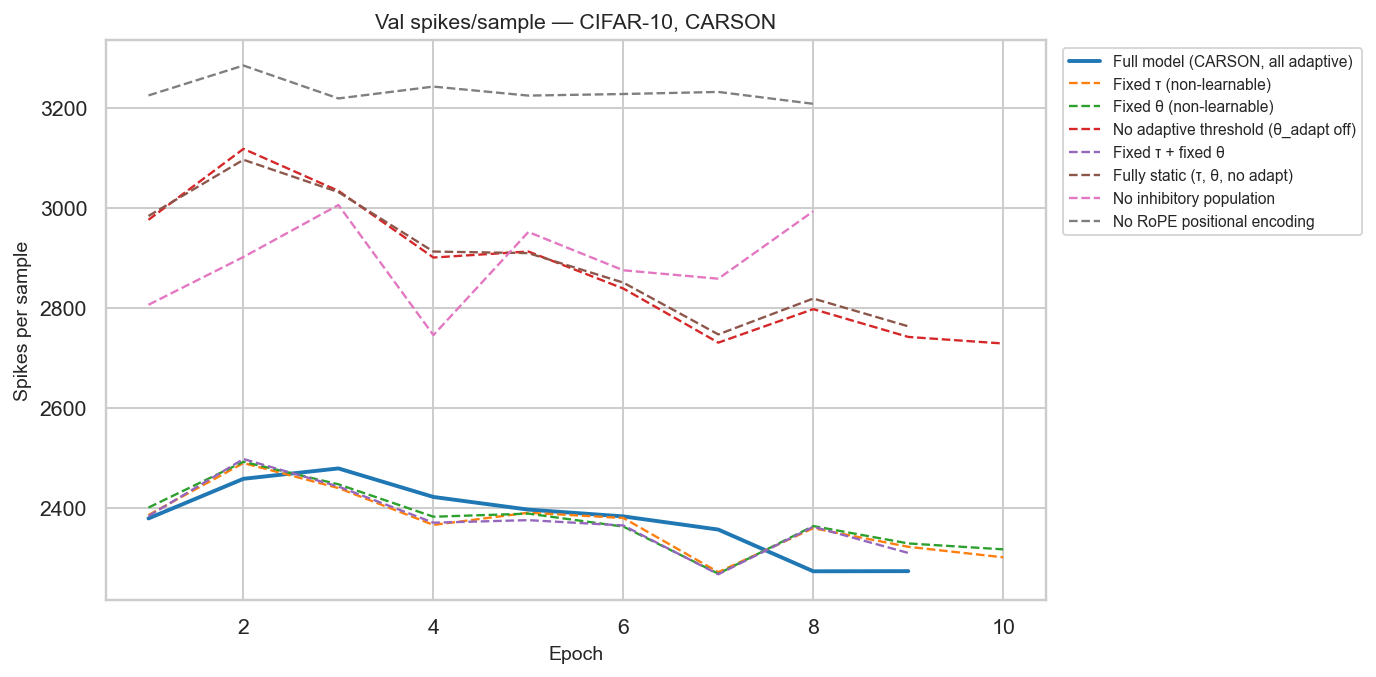

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for (_, row), color in zip(df_all.iterrows(), palette):
    if row["train_log"] is None or not Path(row["train_log"]).exists():
        continue
    tl = pd.read_csv(row["train_log"])
    if "val_spikes_per_sample" not in tl.columns or tl["val_spikes_per_sample"].isna().all():
        continue
    lw = 2.0 if row["cond"] == "full_model" else 1.2
    ls = "-"  if row["cond"] == "full_model" else "--"
    ax.plot(tl["epoch"], tl["val_spikes_per_sample"], label=row["label"],
            color=color, linewidth=lw, linestyle=ls)

ax.set(xlabel="Epoch", ylabel="Spikes per sample",
       title="Val spikes/sample — CIFAR-10, CARSON")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
save(fig, "7b_training_curves_spk_samp_carson")
plt.show()

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\7c_training_curves_entropy_carson.png


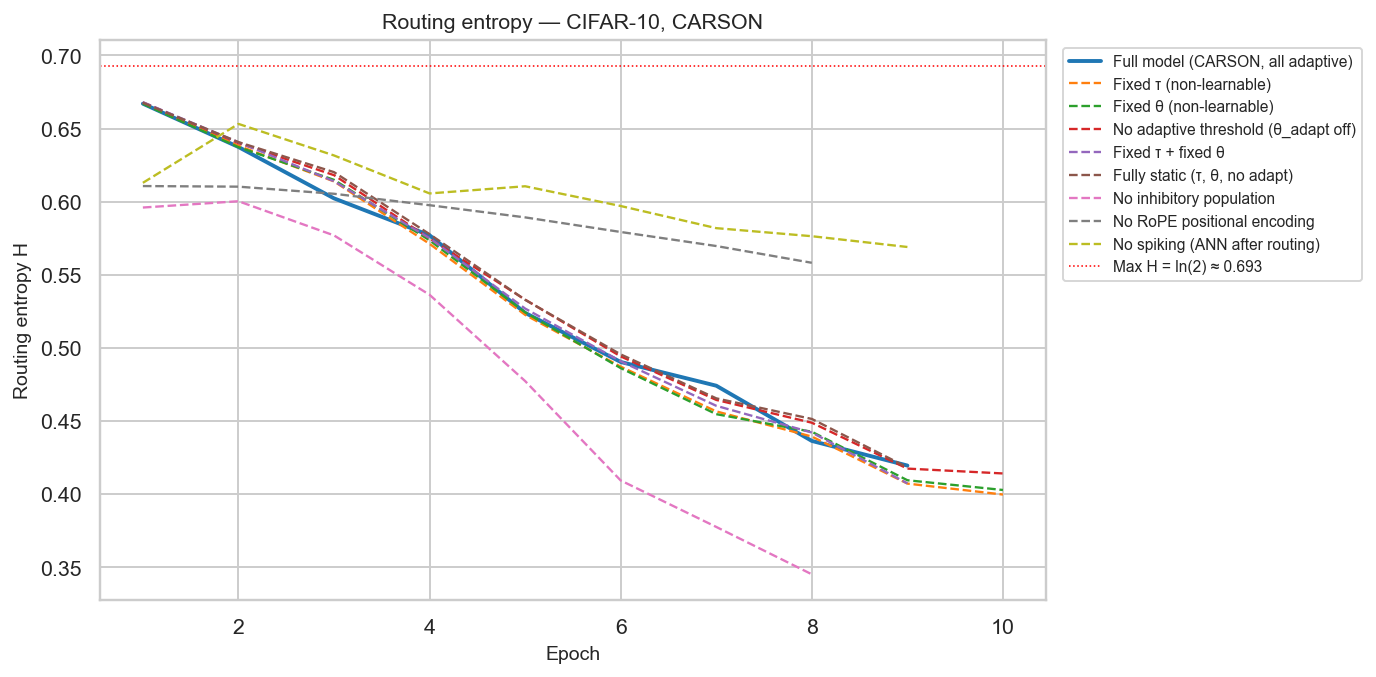

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
for (_, row), color in zip(df_all.iterrows(), palette):
    if row["train_log"] is None or not Path(row["train_log"]).exists():
        continue
    tl = pd.read_csv(row["train_log"])
    if "val_routing_entropy" not in tl.columns:
        continue
    lw = 2.0 if row["cond"] == "full_model" else 1.2
    ls = "-"  if row["cond"] == "full_model" else "--"
    ax.plot(tl["epoch"], tl["val_routing_entropy"], label=row["label"],
            color=color, linewidth=lw, linestyle=ls)

ax.axhline(MAX_ENTROPY, color="red", linewidth=0.8, linestyle=":",
           label=f"Max H = ln(2) ≈ {MAX_ENTROPY:.3f}")
ax.set(xlabel="Epoch", ylabel="Routing entropy H",
       title="Routing entropy — CIFAR-10, CARSON")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
save(fig, "7c_training_curves_entropy_carson")
plt.show()

## 8. Comprehensive Metrics Heatmap (CARSON)

saved → C:\Users\Zohoor Almalki\Projects\CATS\results\ablation_study\cifar10\8_heatmap_carson.png


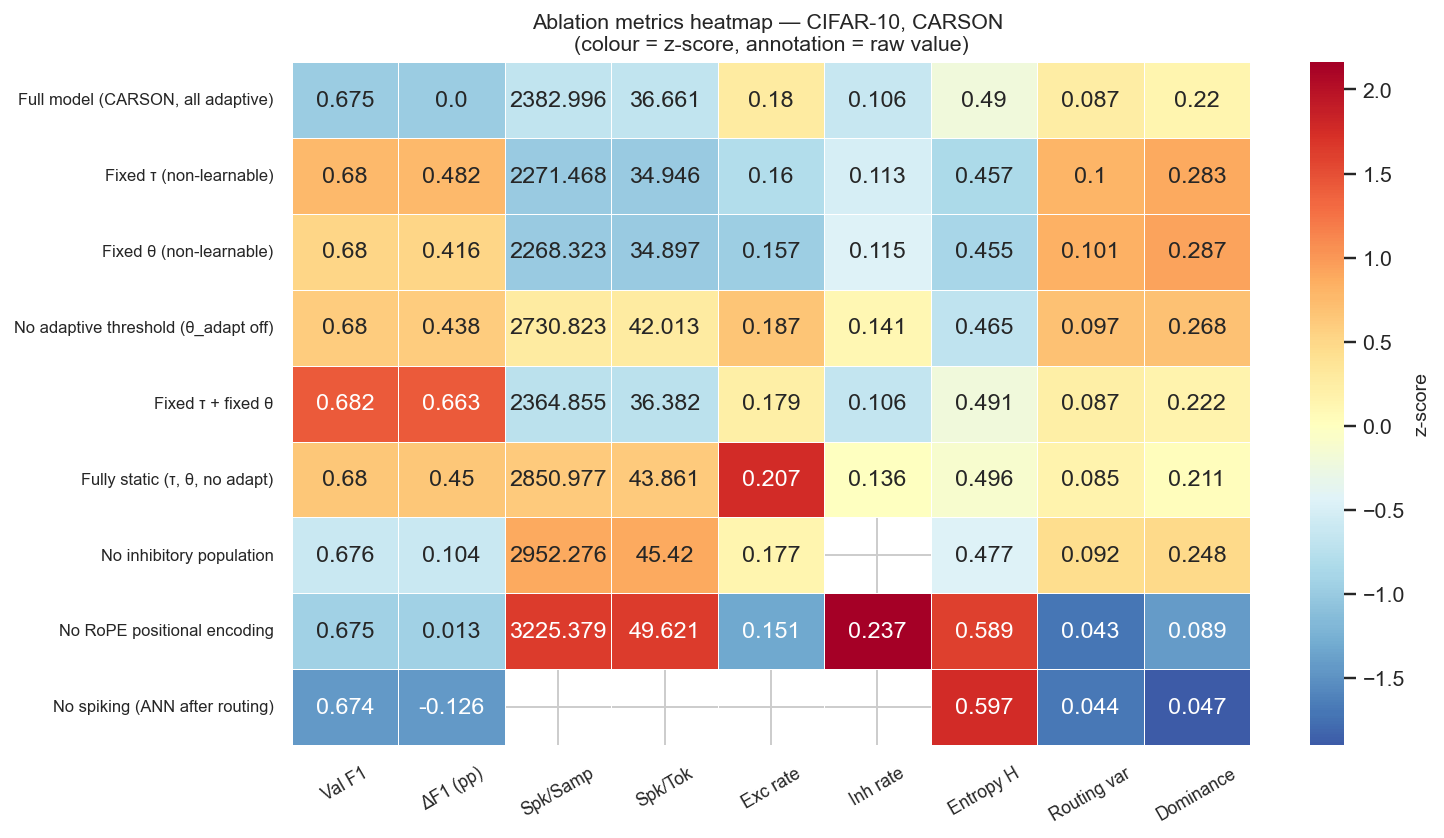

In [19]:
heat_cols = {
    "val_f1":      "Val F1",
    "delta_f1_pp": "ΔF1 (pp)",
    "spk_samp":    "Spk/Samp",
    "spk_tok":     "Spk/Tok",
    "exc_rate":    "Exc rate",
    "inh_rate":    "Inh rate",
    "entropy":     "Entropy H",
    "routing_var": "Routing var",
    "dominance":   "Dominance",
}

heat     = df_all.set_index("label")[list(heat_cols)].rename(columns=heat_cols)
heat_z   = heat.copy()
for col in heat_z.columns:
    col_vals = heat_z[col].dropna()
    if col_vals.std() > 0:
        heat_z[col] = (heat_z[col] - col_vals.mean()) / col_vals.std()

fig, ax = plt.subplots(figsize=(len(heat_cols) * 1.1 + 1, len(df_all) * 0.55 + 1.2))
sns.heatmap(
    heat_z,
    ax=ax,
    annot=heat.round(3),
    fmt="",
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "z-score"},
)
ax.set(title="Ablation metrics heatmap — CIFAR-10, CARSON \n(colour = z-score, annotation = raw value)")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=8.5)
fig.tight_layout()
save(fig, "8_heatmap_carson")
plt.show()

---\n*All plots saved to `results/ablation_study/cifar10/`. Only ANN classifier runs included (`classifier.type != 'snn'`).*